# 09 — Reuse of media appearances × PP↔NM sourcing structure

2. **Canonical NM RV resolution**: when an NM appearance was clipped into Shorts/TikToks,
   the several PP→NM-clip edges are collapsed to a single PP→(original RV) match, so one PP video
   maps to at most one RV. Edges are then deduplicated on `(pp_videoId, nm_rv_id)`.
3. nb10's edge table, diversity metrics and orientation matrix are rebuilt on the deduplicated edges.

# 0. Setup & imports

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx

from scripts.project_config import get_politician_abbr_name

if os.path.isdir("../data/"):
    os.chdir("../")

from src.utils import *
from notebooks.plots_utils import *
from src.transcript_matching import *
from src.file_io import *

%load_ext autoreload
%autoreload 2

rcParams, column_width, page_width, shorts_style, RV_style = get_plt_attr()
plt.rcParams.update(rcParams)

In [2]:
politician2party = get_politician2party()
party_colors = get_parties_color_maps()
party_orientation = get_party_orientation()

# 1. Load channels, videos, transcripts, graphs

### channels

In [3]:
nm_yt_channels = pd.read_json('data/youtube/channels/news_channels.json')
pp_yt_channels = pd.read_json('data/youtube/channels/pp_channels.json')
nm_tt_channels = pd.read_json('data/tiktok/channels/news_channels.json')
pp_tt_channels = pd.read_json('data/tiktok/channels/pp_channels.json')

In [4]:
stat_not_significant_channels = ['Gabriel Attal', 'LP', 'LR', 'RE', 'Rima Hassan', 'UDI']

In [5]:
yt_nm_standard_names = list(nm_yt_channels.name_standard)
yt_pp_standard_names = list(set(list(pp_yt_channels.name_standard)) - set(stat_not_significant_channels))
tt_nm_standard_names = list(nm_tt_channels.name_standard)
tt_pp_standard_names = list(pp_tt_channels.name_standard)

In [6]:
nm_name2orientation = dict(zip(nm_yt_channels.name_standard, nm_yt_channels.orientation))

### videos — YouTube

In [7]:
yt_nm_videos_2022 = pd.read_json("data/youtube/videos/news_videos_2022.jsonl", lines=True)
yt_nm_videos_2024 = pd.read_json("data/youtube/videos/news_videos_2024.jsonl", lines=True)
yt_pp_videos_2022 = pd.read_json("data/youtube/videos/pp_videos_2022.jsonl", lines=True)
yt_pp_videos_2024 = pd.read_json("data/youtube/videos/pp_videos_2024.jsonl", lines=True)
yt_pp_videos_2024 = yt_pp_videos_2024[yt_pp_videos_2024['name_standard']!="MoDem"]
for yt_df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024]:
    yt_df['publishedAt'] = pd.to_datetime(yt_df['publishedAt']).dt.tz_localize(None)
    yt_df['party'] = yt_df['name_standard'].map(politician2party)

### videos — TikTok

In [8]:
tt_nm_videos_2022 = pd.read_json("data/tiktok/videos/news_videos_2022.jsonl", lines=True)
tt_nm_videos_2024 = pd.read_json("data/tiktok/videos/news_videos_2024.jsonl", lines=True)
tt_pp_videos_2022 = pd.read_json("data/tiktok/videos/pp_videos_2022.jsonl", lines=True)
tt_pp_videos_2024 = pd.read_json("data/tiktok/videos/pp_videos_2024.jsonl", lines=True)
for tt_df in [tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    tt_df.rename(columns={'id':'videoId', 'voice_to_text':'transcript','create_time':'publishedAt'}, inplace=True)
    tt_df['videoId'] = tt_df['videoId'].apply(str)
    tt_df['publishedAt'] = pd.to_datetime(tt_df['publishedAt']).dt.tz_localize(None)
    tt_df['party'] = tt_df['name_standard'].map(politician2party)

### lookup dicts

`videoId2publishedAt`, `videoid2standard_name`, and `videoId2yt_type` unified across all 8 DataFrames.
`videoId2yt_type` (from nb09) maps YouTube ids to `'Short'`/`'RV'`; TikTok ids are added as `'TikTok'`
here so the canonical-RV logic below can reason about every node's type uniformly.

In [9]:
# published-at (tz-naive), all platforms/years
videoId2publishedAt = {}
for _df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024,
            tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    videoId2publishedAt.update(dict(zip(_df['videoId'], _df['publishedAt'])))

# videoId -> name_standard (outlet for NM, politician for PP)
videoid2standard_name = {}
for _df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024,
            tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    videoid2standard_name.update(dict(zip(_df['videoId'], _df['name_standard'])))

# videoId -> 'Short'/'RV' for YT (from isShort); 'TikTok' for TT
videoId2yt_type = {}
for _df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024]:
    videoId2yt_type.update(dict(zip(_df['videoId'],
        ['Short' if e else 'RV' for e in _df['isShort']])))
for _df in [tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    videoId2yt_type.update({vid: 'TikTok' for vid in _df['videoId']})

In [10]:
nm_name_standard_list = yt_nm_videos_2024['name_standard'].unique()
pp_name_standard_list = list(set(yt_pp_videos_2024['name_standard'].unique()) - set(stat_not_significant_channels))

### graphs

In [11]:
def load_gs(filepath):
    gs_folder = filepath
    filenames = [filename for filename in os.listdir(gs_folder) if filename[-3:] == '.gv']
    gs = dict()
    for filename in filenames:
        standard_name = filename.split('_')[0]
        gs[standard_name] = nx.nx_agraph.read_dot(gs_folder+filename)
    return gs

In [12]:
gs_pp_only   = load_gs('data/networks/pp_only_2024/')
gs_news_only = load_gs('data/networks/news_only_2024/')
gs_diff      = load_gs('data/networks/diff_2024/')
gs_parties   = load_gs('data/networks/parties_2024/')

In [13]:
def get_platform_from_videoId(videoid):
    return 'yt' if len(str(videoid)) == 11 else 'tt'

# 2. Canonical NM RV resolution (collapse clip fan-out)

**Problem.** The match graph links a PP video to *every* NM node whose transcript overlaps it. When an NM
appearance (the long RV) was also cut by the outlet into Shorts/TikToks, one PP repost produces several
PP->NM edges (one per clip) even though it is a single act of reuse. This inflates every downstream count.

**Fix.** `gs_news_only` links each NM RV to the clips cut from it. We use it to build one dictionary,
`nm_clip2rv`, mapping every NM node (RV or clip) to its original RV. Everything downstream keys on that RV,
so one PP video maps to at most one NM RV.

In [14]:
# Map every NM node to its original RV, using the RV<->clip links in gs_news_only.
# Each connected component in gs_news_only is one appearance: its RV node + the clips cut from it.
# If a component has no RV (e.g. only a Short + TikTok), fall back to the earliest-uploaded node.
def _earliest_node(nodes):
    return min(nodes, key=lambda n: videoId2publishedAt.get(n, pd.Timestamp.max))

nm_clip2rv = {}
for nm_graph in gs_news_only.values():
    g = nm_graph.to_undirected()
    for component in nx.connected_components(g):
        rvs = [n for n in component if videoId2yt_type.get(n) == 'RV']
        canonical = rvs[0] if rvs else _earliest_node(component)   # RV, else earliest upload
        for n in component:
            nm_clip2rv[n] = canonical

print(f"{len(nm_clip2rv)} NM nodes mapped to their canonical video")

40518 NM nodes mapped to their canonical video


# 3. Per-politician metrics: % from NM + elapsed time

Two versions of "% from NM": **uncollapsed** (every PP video that reused any NM appearance) and
**collapsed** (first reposts only, PP re-clips removed). Elapsed time = days between the NM appearance
(canonical RV) and the politician's first repost of it. Both are built from `edges_all` in §4, so this
section runs after it.

In [15]:
def get_video_matches(row, name_standard, gs, platform='both', yt_type='both'):
    """Raw neighbours of a PP video in a match graph (helper for interactive checks)."""
    try:
        videoId = row.videoId.values[0]
    except AttributeError:
        videoId = row.videoId
    if videoId not in gs[name_standard]:
        return ''
    nbrs = list(gs[name_standard][videoId])
    if len(nbrs) == 0:
        return ''
    if platform != 'both':
        return [v for v in nbrs if get_platform_from_videoId(v) == platform]
    if yt_type != 'both':
        return [v for v in nbrs if videoId2yt_type.get(v) == yt_type]
    return nbrs

In [16]:
# Convenience: NM RVs matched by a single PP video (used for spot-checks, not the main pipeline).
def get_canonical_nm_matches(row, name_standard, gs):
    raw = get_video_matches(row, name_standard, gs)
    if raw == '' or len(raw) == 0:
        return []
    return sorted(set(nm_clip2rv.get(v, v) for v in raw))

> **Caveat on elapsed time.** `elapsed_days_*` uses only *first reposts*: PP re-clips (`is_pp_reclip`)
> and PP-first matches are excluded, and it needs a resolvable RV timestamp (`n_with_elapsed`). Where
> `n_with_elapsed` is small the median is noisy — report it with N, consistent with §5.1.

# 4. Directed PP -> NM repost edges from `gs_diff` (canonical + deduplicated)

nb10's `nm_repost_edges`, extended: each NM endpoint is remapped to its canonical RV, then edges are
**deduplicated on `(pp_videoId, nm_rv_id)`**. When several clips of the same RV matched one PP video, the
surviving row keeps the **minimum `|elapsed|`** clip (closest-in-time provenance) and records how many
clip-edges were collapsed (`n_clips_collapsed`) and the clip ids (`collapsed_clip_ids`) for audit.

Direction is recomputed against the **canonical RV timestamp**, so `nm_first`/`pp_first` reflects the RV,
not an arbitrary clip.

In [17]:
def nm_repost_edges(name_standard, gs_diff):
    """PP<->NM matched edges for one politician, with each NM node collapsed to its RV."""
    if name_standard not in gs_diff:
        return pd.DataFrame()
    g = gs_diff[name_standard]
    ntype = nx.get_node_attributes(g, 'type')   # 'nm', 'youtube_pp', 'tiktok_pp' (written by nb07)

    rows = []
    for u, v in g.edges():
        tu, tv = ntype.get(u, ''), ntype.get(v, '')
        if tv == 'nm' and tu in ('youtube_pp', 'tiktok_pp'):
            pp_id, nm_id = u, v
        elif tu == 'nm' and tv in ('youtube_pp', 'tiktok_pp'):
            pp_id, nm_id = v, u
        else:
            continue

        nm_rv = nm_clip2rv.get(nm_id, nm_id)        # collapse clip -> original RV
        pp_pub = videoId2publishedAt.get(pp_id)
        rv_pub = videoId2publishedAt.get(nm_rv)
        elapsed = direction = None
        if pp_pub is not None and rv_pub is not None:
            elapsed = (pp_pub - rv_pub).total_seconds()
            direction = 'nm_first' if rv_pub < pp_pub else 'pp_first'

        rows.append({
            'name_standard': name_standard,
            'party': politician2party.get(name_standard),
            'pp_videoId': pp_id,
            'pp_platform': get_platform_from_videoId(pp_id),
            'nm_videoId': nm_rv,                     # canonical RV (analysis key)
            'nm_outlet': videoid2standard_name.get(nm_rv),
            'nm_orientation': None,
            'elapsed_sec': elapsed,
            'direction': direction,                 # timestamp-based (independent evidence)
        })

    df = pd.DataFrame(rows)
    if not len(df):
        return df

    # One row per (PP video, NM RV): drops duplicate edges from several clips of the same RV.
    df = df.sort_values('elapsed_sec').drop_duplicates(['pp_videoId', 'nm_videoId'], keep='first')

    # Content-based direction: a PP video linked to >1 distinct NM CHANNEL means the outlets
    # picked up the politician's footage (reverse direction). One channel => PP sourced from NM,
    # even if the PP posted first (they still got the footage from that outlet's appearance).
    n_channels = df.groupby('pp_videoId')['nm_outlet'].transform('nunique')
    df['reuse_direction'] = np.where(n_channels > 1, 'pp_to_nm', 'nm_to_pp')

    # Flag PP re-clips among genuine reposts: keep only the FIRST repost of each RV as the real one.
    df = df.sort_values('elapsed_sec')  # smallest elapsed = earliest PP post relative to RV
    first = df.groupby(['name_standard', 'nm_videoId']).head(1).index
    df['is_pp_reclip'] = ~df.index.isin(first)

    df['nm_orientation'] = df['nm_outlet'].map(nm_name2orientation)
    return df

edges_all = pd.concat([nm_repost_edges(n, gs_diff) for n in yt_pp_standard_names],
                      ignore_index=True)
print(f"Total PP<->NM edges (one per PP video / NM RV): {len(edges_all)}")
print(edges_all['direction'].value_counts(dropna=False))
print(edges_all['reuse_direction'].value_counts(dropna=False))
edges_all.head()

Total PP<->NM edges (one per PP video / NM RV): 1301
direction
nm_first    881
pp_first    398
None         22
Name: count, dtype: int64
reuse_direction
pp_to_nm    715
nm_to_pp    586
Name: count, dtype: int64


,name_standard,party,pp_videoId,pp_platform,nm_videoId,nm_outlet,nm_orientation,elapsed_sec,direction,reuse_direction,is_pp_reclip
0,Marion Maréchal,REC,7379949069847874848,tt,-dLG1YcBdVY,LCI,Right (news),-253700.0,pp_first,nm_to_pp,False
1,Marion Maréchal,REC,sogU-TUJn_0,yt,7366182605131173153,RTL,Center (news),-145185.0,pp_first,nm_to_pp,False
2,Marion Maréchal,REC,7361511387857734945,tt,aS6YoCBEXv4,Europe 1,Right (news),-45675.0,pp_first,nm_to_pp,False
3,Marion Maréchal,REC,nJ-S03wgUwM,yt,aS6YoCBEXv4,Europe 1,Right (news),-42561.0,pp_first,nm_to_pp,True
4,Marion Maréchal,REC,7355585712751775008,tt,tkFAzDwQGus,Europe 1,Right (news),-41333.0,pp_first,nm_to_pp,False


In [18]:
# sanity: every (PP video, NM RV) pair appears once
dups = edges_all.duplicated(subset=['pp_videoId', 'nm_videoId']).sum()
print("duplicate (pp, nm_rv) pairs:", int(dups), "(expected 0)")
print("PP re-clips flagged:", int(edges_all['is_pp_reclip'].sum()),
      "of", len(edges_all), "edges")

duplicate (pp, nm_rv) pairs: 0 (expected 0)
PP re-clips flagged: 608 of 1301 edges


- Eric Zemmour, le lien est correct, mais 5/5 ce n'est pas un repost en 1er
- PS, politicien a repost avant la video nm 4/4 sauf quand des videos de différents media ont un lien avec une video du pp et là c'était des reposts pp -> nm, d'un discours du pp
- macron cas bizarre : 7342980306846190880 les NM ont toutes un extrait d'une allocution d'EM mais ce n'est pas celle là, mais un discours quasi identique, masi bon OSEF, ensuite c'est toujours ses annonces qui sont reprise par les media quand il poste en 1er
- marion marechal : nm -> pp 5/5
- françois ruffin : quand unique c'est correct nm -> pp, quand several c'est pp -> nm
- EELV mostly correct
- 

In [19]:
edges_all.name_standard.unique()

<StringArray>
[      'Marion Maréchal',                  'EELV',   'François Asselineau',
       'François Ruffin',                 'MoDem', 'Nicolas Dupont-Aignan',
        'Mathilde Panot',     'Florian Philippot',                    'RN',
                    'PS',       'Jordan Bardella',    'Jean-Luc Mélenchon',
                   'NPA',           'Manon Aubry',        'Manuel Bompard',
          'Éric Zemmour',                    'PP',                   'LFI',
         'Marine Le Pen',                   'PCF',       'Emmanuel Macron',
                   'UPR']
Length: 22, dtype: str

In [20]:
def to_url(vid):
    vid = str(vid)
    # TikTok IDs are numeric (typically 19 digits); YouTube IDs are 11-char alphanumeric with - and _
    if vid.isdigit():
        return f"https://www.tiktok.com/@x/video/{vid}"
    else:
        return f"https://www.youtube.com/watch?v={vid}"

filtered_edges = edges_all[
    (edges_all['direction'] == 'pp_first') &
    (edges_all['name_standard'] == 'RN')
].sort_values(by='pp_videoId')

for pp_videoId, nm_videoId in zip(filtered_edges['pp_videoId'], filtered_edges['nm_videoId']):
    print(to_url(pp_videoId), to_url(nm_videoId))

https://www.tiktok.com/@x/video/7386682609847242017 https://www.youtube.com/watch?v=X9jSpRdzFTk


In [21]:
# ---- Build clip -> parent RV map from gs_pp_only ----------------------------
# Each component: one RV + the Shorts/TikToks cut from it. Some components are a lone
# clip with no RV (clip that isn't cut from anything) -> no parent.
pp_clip2rv = {}          # clip videoId -> parent RV videoId
pp_all_clip_ids = set()  # every Short/TikTok node seen in gs_pp_only
multi_rv_components = 0

for outlet_graph in gs_pp_only.values():
    g = outlet_graph.to_undirected()
    for component in nx.connected_components(g):
        rvs   = [x for x in component if videoId2yt_type.get(x) == 'RV']
        clips = [x for x in component if videoId2yt_type.get(x) in ('Short', 'TikTok')]
        pp_all_clip_ids.update(clips)
        if len(rvs) > 1:
            multi_rv_components += 1
        rv = rvs[0] if rvs else None
        if rv is not None:
            for c in clips:
                pp_clip2rv[c] = rv     # clips in a no-RV component simply get no parent

print(f"{len(pp_all_clip_ids)} PP clips seen | {len(pp_clip2rv)} have a parent RV "
      f"| {multi_rv_components} multi-RV components (should be 0)")

# ---- Reposts: NM->PP, not a reclip. NO timing filter (a repost is defined by NM origin). ----
reposts = edges_all[(~edges_all['is_pp_reclip']) & (edges_all['reuse_direction'] == 'nm_to_pp')]

reposted_rv_by_polit = reposts.groupby('name_standard')['pp_videoId'].agg(set).to_dict()

clip_owner = videoid2standard_name

metrics = dict()
for name_standard in pp_name_standard_list:
    n_yt = (yt_pp_videos_2024.name_standard == name_standard).sum()
    n_tt = (tt_pp_videos_2024.name_standard == name_standard).sum()
    n_pp_videos = int(n_yt + n_tt)

    e  = edges_all[edges_all['name_standard'] == name_standard]
    rp = reposts[reposts['name_standard'] == name_standard]

    # % of all videos that are reposts (uncollapsed = any NM-linked; collapsed = distinct reposts)
    n_from_nm_uncollapsed = e[e['reuse_direction'] == 'nm_to_pp']['pp_videoId'].nunique()
    n_from_nm_collapsed   = rp['pp_videoId'].nunique()

    # (B1) share of this politician's clips that descend from a reposted RV
    reposted_rvs = reposted_rv_by_polit.get(name_standard, set())
    my_clips = [c for c in pp_all_clip_ids if clip_owner.get(c) == name_standard]
    n_clips = len(my_clips)
    n_clips_from_repost = sum(1 for c in my_clips if pp_clip2rv.get(c) in reposted_rvs)
    reclip_share = 100*(n_clips_from_repost / n_clips) if n_clips else np.nan

    # elapsed: only reposts with a defined positive lag (appearance predates the PP post)
    lag = rp['elapsed_sec']
    lag_pos = lag[lag > 0] / 86400.0
    n_neg = int((lag <= 0).sum())          # reposts where PP posted first (no lag defined)
    n_e = len(lag_pos)
    sem = float(lag_pos.std(ddof=1) / np.sqrt(n_e)) if n_e > 1 else np.nan

    metrics[name_standard] = {
        'n_pp_videos':            n_pp_videos,
        '% from NM':              100 * n_from_nm_uncollapsed / n_pp_videos if n_pp_videos else np.nan,
        '% from NM (collapsed)':  100 * n_from_nm_collapsed / n_pp_videos if n_pp_videos else np.nan,
        'n_from_NM':              int(n_from_nm_uncollapsed),
        'n_from_NM (collapsed)':  int(n_from_nm_collapsed),
        '% clips from NM':           reclip_share,
        'n_clips':                int(n_clips),
        'n_clips_from_repost':    int(n_clips_from_repost),
        'elapsed_days_mean':      float(lag_pos.mean())      if n_e else np.nan,
        'elapsed_days_std':       float(lag_pos.std(ddof=1)) if n_e > 1 else np.nan,
        'sem_elapsed_days':       sem,
        'n_with_elapsed':         int(n_e),
        'n_pp_first_reposts':     n_neg,
    }

metrics_df = pd.DataFrame(metrics).T.sort_values('% from NM (collapsed)', ascending=False)
metrics_df

2594 PP clips seen | 804 have a parent RV | 27 multi-RV components (should be 0)


,n_pp_videos,% from NM,% from NM (collapsed),n_from_NM,n_from_NM (collapsed),% clips from NM,n_clips,n_clips_from_repost,elapsed_days_mean,elapsed_days_std,sem_elapsed_days,n_with_elapsed,n_pp_first_reposts
Manuel Bompard,124.0,27.419355,17.741935,34.0,22.0,32.758621,58.0,19.0,0.103312,0.238274,0.057790,17.0,7.0
EELV,116.0,18.103448,15.517241,21.0,18.0,5.263158,19.0,1.0,1.354197,3.364016,0.815894,17.0,1.0
Manon Aubry,271.0,25.830258,15.129151,70.0,41.0,17.088608,158.0,27.0,0.446287,0.634691,0.112199,32.0,13.0
Éric Zemmour,78.0,25.641026,14.102564,20.0,11.0,21.621622,37.0,8.0,0.053702,0.021766,0.008227,7.0,6.0
PS,123.0,12.195122,11.382114,15.0,14.0,2.439024,41.0,1.0,0.951193,0.912010,0.288403,10.0,4.0
Marion Maréchal,237.0,22.784810,8.860759,54.0,21.0,6.369427,157.0,10.0,0.107886,0.122920,0.031738,15.0,6.0
RN,393.0,17.557252,8.396947,69.0,33.0,0.000000,351.0,0.0,2.738124,3.629837,0.622512,34.0,0.0
PP,193.0,18.134715,7.772021,35.0,15.0,4.545455,22.0,1.0,0.637078,0.774445,0.244901,10.0,5.0
Jordan Bardella,287.0,16.376307,7.317073,47.0,21.0,5.208333,192.0,10.0,1.142884,0.915101,0.236278,15.0,8.0
Mathilde Panot,127.0,14.173228,7.086614,18.0,9.0,15.384615,65.0,10.0,4.795837,8.295590,4.789461,3.0,6.0


In [24]:
# ---- P(clipped): own RVs (RV_o) vs. reposted NM appearances (RV_r) --------------
# Needs from cell 33: pp_clip2rv, pp_all_clip_ids, reposts, reposted_rv_by_polit, clip_owner.
# Must run BEFORE the figure cell (cell 34) and the Wilcoxon cell (cell 36).
from collections import Counter

# Which RVs count as "source videos":
#   'all'   -> every 2024 YouTube RV of the channel (with or without transcript)
#   'graph' -> only RVs that are nodes of the channel's clipping graph gs_pp_only
RV_UNIVERSE = 'all'

rows = {}
for name_standard in pp_name_standard_list:
    ch = yt_pp_videos_2024[yt_pp_videos_2024['name_standard'] == name_standard]
    rv_ids = set(ch.loc[~ch['isShort'].fillna(False).astype(bool), 'videoId'])
    if RV_UNIVERSE == 'graph':
        g = gs_pp_only.get(name_standard)
        rv_ids &= set(g.nodes) if g is not None else set()

    # RV_r: the channel's RVs that are first reposts of an NM appearance (nm_to_pp, not a re-clip)
    reposted = reposted_rv_by_polit.get(name_standard, set())
    rv_r = {v for v in reposted if videoId2yt_type.get(v) == 'RV'} & rv_ids
    # RV_o: all other RVs = the politician's own content
    rv_o = rv_ids - rv_r

    # number of clips (Shorts + TikToks) attached to each parent RV
    my_clips = [c for c in pp_all_clip_ids if clip_owner.get(c) == name_standard]
    clips_per_parent = Counter(pp_clip2rv[c] for c in my_clips if c in pp_clip2rv)

    Co = sum(n for rv, n in clips_per_parent.items() if rv in rv_o)
    Cr = sum(n for rv, n in clips_per_parent.items() if rv in rv_r)
    clipped_o = sum(1 for rv in rv_o if clips_per_parent.get(rv, 0) > 0)
    clipped_r = sum(1 for rv in rv_r if clips_per_parent.get(rv, 0) > 0)

    n_RVo, n_RVr = len(rv_o), len(rv_r)
    p_own = clipped_o / n_RVo if n_RVo else np.nan
    p_rep = clipped_r / n_RVr if n_RVr else np.nan

    rows[name_standard] = {
        'n_RVo': n_RVo,
        'n_RVr': n_RVr,
        'p_clip_own': p_own,
        'p_clip_repost': p_rep,
        'clips_per_own': Co / n_RVo if n_RVo else np.nan,
        'clips_per_repost': Cr / n_RVr if n_RVr else np.nan,
        'Co': Co,
        'Cr': Cr,
        'favors_appearances_p': p_rep - p_own,   # NaN if either side undefined
    }

clipping_df = (pd.DataFrame(rows).T
               .astype(float)
               .sort_values('favors_appearances_p', ascending=False, na_position='last'))
clipping_df

,n_RVo,n_RVr,p_clip_own,p_clip_repost,clips_per_own,clips_per_repost,Co,Cr,favors_appearances_p
Mathilde Panot,52.0,7.0,0.307692,0.714286,0.615385,1.428571,32.0,10.0,0.406593
Marine Le Pen,22.0,2.0,0.636364,1.000000,1.363636,4.000000,30.0,8.0,0.363636
Éric Zemmour,22.0,8.0,0.272727,0.500000,0.454545,1.000000,10.0,8.0,0.227273
Jean-Luc Mélenchon,64.0,5.0,0.578125,0.800000,1.593750,2.800000,102.0,14.0,0.221875
Nicolas Dupont-Aignan,32.0,4.0,0.281250,0.500000,0.468750,0.750000,15.0,3.0,0.218750
François Ruffin,16.0,3.0,0.875000,1.000000,2.125000,3.333333,34.0,10.0,0.125000
Jordan Bardella,56.0,5.0,0.482143,0.600000,0.928571,2.000000,52.0,10.0,0.117857
Manon Aubry,72.0,37.0,0.347222,0.432432,0.527778,0.729730,38.0,27.0,0.085210
PP,154.0,15.0,0.006494,0.066667,0.006494,0.066667,1.0,1.0,0.060173
Emmanuel Macron,14.0,3.0,0.285714,0.333333,0.285714,4.333333,4.0,13.0,0.047619


/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_25753/1781616051.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


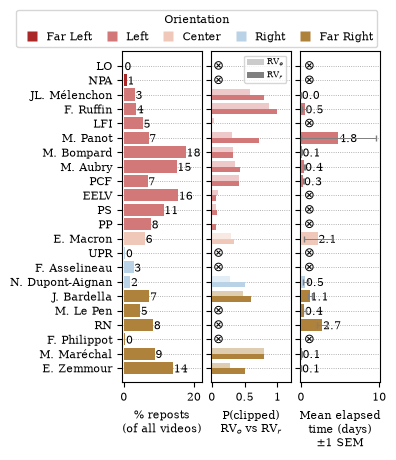

In [30]:
# ---- Per-politician bar plots: % from NM | clipping rates | elapsed time -----
color_map = get_politic_news_color_maps()
polit2party = get_politician2party()
party2orientation = get_party_orientation()

df = metrics_df.dropna(subset=['% from NM (collapsed)']).copy()

# pull the two clipping probabilities onto df (NaN where politician wasn't in the 16)
df['p_clip_own']    = clipping_df['p_clip_own'].reindex(df.index)
df['p_clip_repost'] = clipping_df['p_clip_repost'].reindex(df.index)
# only show rates where both source types had support (same rule as the test)
enough_rates = (clipping_df['n_RVo'].reindex(df.index) >= 3) & \
               (clipping_df['n_RVr'].reindex(df.index) >= 3)
df.loc[~enough_rates.fillna(False), ['p_clip_own', 'p_clip_repost']] = np.nan

orient_order = ['Far Left', 'Left', 'Center', 'Right', 'Far Right']
party_order = ['LO','NPA','LFI','PCF','EELV','PS','EcoS','PP','DG','RE','MoDem',
               'UDI','HOR','UPR','LR','DD','DLF','RN','LP','REC','autre']
df['_party']  = [polit2party[n] for n in df.index]
df['_orient'] = [party2orientation[polit2party[n]] for n in df.index]
df['_party_rank'] = df['_party'].apply(
    lambda o: party_order.index(o) if o in party_order else len(party_order))
df = df.sort_values('_party_rank')

politicians = list(df.index)
abbr = get_politician_abbr_name()
politician_labels = [abbr.get(p, p) for p in politicians]
colors = [color_map[o] for o in df['_orient']]
n = len(politicians)

EDGE_THRESH = 24
n_edges = np.array([len(gs_pp_only[p].edges()) if p in gs_pp_only else 0 for p in politicians])
enough = n_edges >= EDGE_THRESH

y = np.arange(n)
bar_h = 0.85

fig, axes = plt.subplots(
    1, 3, figsize=(column_width, 0.15 * n + 1), sharey=True,
    gridspec_kw={'wspace': 0.12}
)
ax_nm, ax_clip, ax_time = axes

# ---- 1) % from NM (collapsed) ----
pct = df['% from NM (collapsed)'].to_numpy()
ax_nm.barh(y, pct, height=bar_h, color=colors, zorder=3)
ax_nm.set_xlabel('% reposts\n(of all videos)')
ax_nm.set_yticks(y); ax_nm.set_yticklabels(politician_labels)
ax_nm.invert_yaxis()
for yi, v in enumerate(pct):
    if not np.isnan(v):
        ax_nm.text(v + 0.01 * np.nanmax(pct), yi + 0.1, f'{v:.0f}', va='center', ha='left')
pct_xmax = np.nanmax(np.nan_to_num(pct))
ax_nm.set_xlim(-0.5, 1.25 * pct_xmax)

# ---- 2) clipping rates: own RVs vs reposted appearances (orientation color, hatch = source) ----
p_own = df['p_clip_own'].to_numpy()
p_rep = df['p_clip_repost'].to_numpy()
sub_h = bar_h / 2 * 0.9
ax_clip.barh(y - sub_h/2, p_own, height=sub_h, color=colors, alpha=0.4, zorder=3)
ax_clip.barh(y + sub_h/2, p_rep, height=sub_h, color=colors, alpha=1.0, zorder=3)
ax_clip.set_xlabel('P(clipped)\nRV$_o$ vs RV$_r$')
ax_clip.set_xlim(-0.01, 1.20); ax_clip.set_xticks([0, 0.5, 1]); ax_clip.set_xticklabels(['0','0.5','1'])

for yi in range(n):
    if np.isnan(p_own[yi]) and np.isnan(p_rep[yi]):
        ax_clip.text(0.02, yi + 0.1, s='$\\otimes$', fontsize=9,
                     va='center', ha='left', color='k')
#for yi in range(n):
#    if not np.isnan(p_own[yi]):
#        ax_clip.text(p_own[yi] + 0.01, yi - sub_h/2, f'{p_own[yi]:.2f}',
#                     va='center', ha='left', fontsize=5.5)
#    if not np.isnan(p_rep[yi]):
#        ax_clip.text(p_rep[yi] + 0.01, yi + sub_h/2, f'{p_rep[yi]:.2f}',
#                     va='center', ha='left', fontsize=5.5)

# hatch legend (source), colour-neutral so it reads as "pattern = source, colour = orientation"
clip_handles = [
    Patch(facecolor='0.5', alpha=0.4, label='RV$_o$'),
    Patch(facecolor='0.5', alpha=1.0, label='RV$_r$'),
]
ax_clip.legend(handles=clip_handles, loc='upper right', fontsize=6,
               frameon=True, handletextpad=0.4, borderpad=0.3)

# ---- 3) elapsed time (days) ±SEM, gated by edge threshold ----
elapsed_days = df['elapsed_days_mean'].to_numpy()
elapsed_err  = df['sem_elapsed_days'].to_numpy()
elapsed_days_plot = np.where(enough, elapsed_days, np.nan)
elapsed_err_plot  = np.where(enough, elapsed_err, np.nan)

ax_time.barh(y, elapsed_days_plot, height=bar_h, color=colors,
             xerr=elapsed_err_plot, error_kw=dict(ecolor='0.5', lw=0.7, capsize=2), zorder=3)
ax_time.set_xlabel('Mean elapsed\ntime (days)\n±1 SEM')
time_xmax = np.nanmax(elapsed_days_plot + np.nan_to_num(elapsed_err_plot))
for yi in range(n):
    if enough[yi] and not np.isnan(elapsed_days[yi]):
        ax_time.text(elapsed_days[yi] + 0.01 * time_xmax, yi + 0.1,
                     f'{elapsed_days[yi]:.1f}', va='center', ha='left')
    else:
        ax_time.text(0.04 * time_xmax, yi + 0.1, s='$\\otimes$', fontsize=9,
                     va='center', ha='left', color='k')
ax_time.set_xlim(left=-0.01 * time_xmax)

# ---- grid + limits ----
for ax in (ax_nm, ax_clip, ax_time):
    ax.grid(axis='y', linestyle=':', color='0.6', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
ax_time.set_ylim(n, -1)

present = [o for o in orient_order if o in set(df['_orient'])]
legend_handles = [Line2D([0], [0], marker='s', linestyle='', markersize=7,
                         markerfacecolor=color_map[o], markeredgecolor='none', label=o)
                  for o in present]
fig.legend(handles=legend_handles, loc='upper center', ncol=len(present) + 1,
           frameon=True, title='Orientation', bbox_to_anchor=(0.35, 0.99),
           columnspacing=0.8, handletextpad=0.3, borderpad=0.4)

plt.tight_layout()
fig.savefig('Figures/barplots_reposts_patterns.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/barplots_reposts_patterns.pdf',
            bbox_inches='tight')
plt.show()

In [26]:
from scipy.stats import wilcoxon
paired = clipping_df.dropna(subset=['p_clip_own', 'p_clip_repost'])
paired = paired[(paired['n_RVo'] >= 3) & (paired['n_RVr'] >= 3)]   # minimal support
stat, pval = wilcoxon(paired['p_clip_repost'], paired['p_clip_own'])
print(f"n politicians compared: {len(paired)}")
print(f"median p_clip_repost = {paired['p_clip_repost'].median():.3f}, "
      f"median p_clip_own = {paired['p_clip_own'].median():.3f}")
print(f"Wilcoxon signed-rank: stat={stat:.1f}, p={pval:.4f}")

n politicians compared: 15
median p_clip_repost = 0.432, median p_clip_own = 0.308
Wilcoxon signed-rank: stat=15.0, p=0.0084


# TO DO : NEED TO VERIFY IN OTHER WAY THAN ELAPSED TIME WHO CLIPS WHO

**Directionality result (already a finding).** `direction.value_counts()` tells you how often outlets
clip politicians (`pp_first`) vs. politicians repost outlets (`nm_first`). For a clean "reuse of media
appearances" story, restrict to `nm_first`. Toggle below.

In [30]:
RESTRICT_TO_NM_FIRST = False
edges = edges_all[edges_all['direction'] == 'nm_first'].copy() if RESTRICT_TO_NM_FIRST else edges_all.copy()
edges_collapsed = edges[~edges['is_pp_reclip']].copy()   # first PP repost per NM RV
print(f"Using {len(edges)} edges (uncollapsed) | {len(edges_collapsed)} after PP-side collapse")

Using 1246 edges (uncollapsed) | 667 after PP-side collapse


## #1 — Bipartite sourcing graph + source-diversity metrics

Weighted bipartite graph politician -> NM outlet, weight = number of reposts (now counted on canonical RVs,
so a clipped appearance is one repost, not several). Concentration metrics per politician; low-support rows
flagged.

In [31]:
def diversity_metrics(sub):
    """sub: rows for one politician. Returns entropy/HHI/effective-N over NM outlets."""
    w = sub.groupby('nm_outlet').size()
    w = w[w.index.notna()]
    total = int(w.sum())
    if total == 0:
        return dict(n_reposts=0, n_outlets=0, shannon_entropy=np.nan,
                    norm_entropy=np.nan, hhi=np.nan, eff_n_outlets=np.nan, top_outlet=None)
    p = (w / w.sum()).values
    H = float(-(p * np.log(p)).sum())
    k = len(p)
    normH = H / np.log(k) if k > 1 else 0.0
    hhi = float((p ** 2).sum())
    n_reposts = len(sub['pp_videoId'].unique())
    return dict(n_reposts=n_reposts, n_outlets=k, shannon_entropy=H,
                norm_entropy=normH, hhi=hhi, eff_n_outlets=float(np.exp(H)),
                top_outlet=w.idxmax())

div = (edges.groupby('name_standard', group_keys=False)
            .apply(lambda s: pd.Series(diversity_metrics(s)))
            .reset_index())
div['party'] = div['name_standard'].map(politician2party)
div = div.sort_values('n_reposts', ascending=False)
div

,name_standard,n_reposts,n_outlets,shannon_entropy,norm_entropy,hhi,eff_n_outlets,top_outlet,party
19,RN,86,16,2.304525,0.831182,0.133845,10.019415,Europe 1,RN
6,Jordan Bardella,68,22,2.615638,0.846199,0.105913,13.675940,BFMTV,RN
8,Manon Aubry,68,16,2.245976,0.810065,0.154092,9.449638,Europe 1,LFI
16,PCF,67,14,2.346761,0.889242,0.111760,10.451665,LCI,PCF
11,Marion Maréchal,56,10,2.021868,0.878086,0.157648,7.552420,Europe 1,REC
9,Manuel Bompard,46,13,2.018046,0.786778,0.191346,7.523607,LCI,LFI
10,Marine Le Pen,45,20,2.732651,0.912181,0.082268,15.373586,BFMTV,RN
17,PP,36,14,2.348138,0.889764,0.115702,10.466065,France Inter,PP
5,Jean-Luc Mélenchon,33,20,2.792893,0.932291,0.070382,16.328189,BFMTV,LFI
0,EELV,31,18,2.755640,0.953386,0.069824,15.731111,BFMTV,EELV


### Build & (optionally) export the weighted bipartite graph object

In [32]:
B = nx.Graph()
for n in edges['name_standard'].unique():
    B.add_node(('PP', n), bipartite='pp', party=politician2party.get(n))
for o in edges['nm_outlet'].dropna().unique():
    B.add_node(('NM', o), bipartite='nm', orientation=nm_name2orientation.get(o))
for (n, o), w in edges.dropna(subset=['nm_outlet']).groupby(['name_standard','nm_outlet']).size().items():
    B.add_edge(('PP', n), ('NM', o), weight=int(w))

print(f"Bipartite graph: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")

nm_strength = (edges.dropna(subset=['nm_outlet'])
                    .groupby('nm_outlet').size().sort_values(ascending=False))
nm_strength.head(15)

Bipartite graph: 53 nodes, 258 edges


nm_outlet
BFMTV           197
Europe 1        168
LCI             110
TF1 INFO         83
Public Sénat     73
FRANCE 24        68
RMC              61
AFP              54
Sud Radio        53
LCP              49
franceinfo       41
Le Figaro        33
France Inter     32
RTL              31
Le Parisien      30
dtype: int64

### Figure #1a — source-diversity bar (normalized entropy), colored by party, N annotated

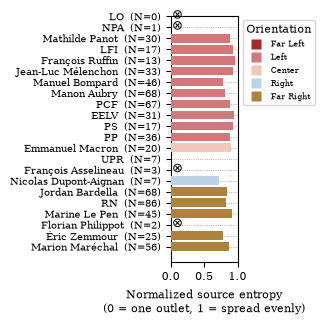

In [103]:
color_map = get_politic_news_color_maps()
polit2party = get_politician2party()
party2orientation = get_party_orientation()

orient_order = ['Far Left', 'Left', 'Center', 'Right', 'Far Right']

MIN_SUPPORT = 5

# start from ALL politicians, bring in entropy/support where it exists
d = pd.DataFrame({'name_standard': list(pp_name_standard_list)})
div_idx = div.set_index('name_standard')
d['norm_entropy'] = d['name_standard'].map(div_idx['norm_entropy'])
d['n_reposts']    = d['name_standard'].map(div_idx['n_reposts']).fillna(0).astype(int)

d['_party']  = [polit2party[p] for p in d['name_standard']]
d['_orient'] = [party2orientation[polit2party[p]] for p in d['name_standard']]
d['_rank']   = d['_party'].apply(lambda p: party_order.index(p) if p in party_order else len(party_order))
d = d.sort_values('_rank').reset_index(drop=True)

d['_ok'] = d['n_reposts'] >= MIN_SUPPORT
ent = np.where(d['_ok'], d['norm_entropy'], np.nan)
colors = [color_map[o] for o in d['_orient']]

fig, ax = plt.subplots(figsize=(column_width, max(3, 0.15*len(d))))

ax.barh(range(len(d)), ent, color=colors, zorder=3)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{name}  (N={int(nn)})"
                    for name, nn in zip(d['name_standard'], d['n_reposts'])], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Normalized source entropy\n(0 = one outlet, 1 = spread evenly)')
ax.set_xlim(0, 1)
ax.grid(axis='y', linestyle=':', color='0.6', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

for yi, ok in enumerate(d['_ok'].to_numpy()):
    if not ok:
        ax.text(0.02, yi, s='$\\otimes$', fontsize=9, va='center', ha='left', color='k', zorder=4)

present = [o for o in orient_order if o in set(d['_orient'])]
handles = [Line2D([0], [0], marker='s', linestyle='', markersize=7,
                  markerfacecolor=color_map[o], markeredgecolor='none', label=o)
           for o in present]
ax.legend(handles=handles, title='Orientation', bbox_to_anchor=(1.02, 1),
          loc='upper left', ncol=1, fontsize=6)

plt.tight_layout()
# fig.savefig('Figures/nm_source_diversity.pdf', bbox_inches='tight')
plt.show()

## #2 — PP-orientation × NM-orientation reuse matrix

Rows = political family of the reposting politician; columns = orientation of the NM outlet. Counts are on
canonical RVs. Row-normalized answers "where does each family source from?"; raw counts show volume.

In [120]:
m = edges.dropna(subset=['nm_orientation']).copy()
m['pp_orientation'] = m['party'].map(party_orientation)

row_order = ['Left','Center','Far Right']
col_order = ['Center (news)','Right (news)']
ct = (m.groupby(['pp_orientation','nm_orientation']).size()
        .unstack(fill_value=0)
        .reindex(index=row_order, columns=col_order, fill_value=0))
ct_raw = ct.copy()
ct_row = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)

print("Raw counts:"); print(ct_raw)
ct_row


Raw counts:
nm_orientation  Center (news)  Right (news)
pp_orientation                             
Left                      256           338
Center                     57            69
Far Right                 127           367


nm_orientation,Center (news),Right (news)
pp_orientation,,
Left,0.430976,0.569024
Center,0.452381,0.547619
Far Right,0.257085,0.742915


### Figure #2 — cross-orientation heatmap (row-normalized)

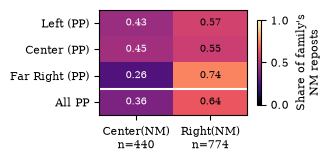

In [124]:
# overall distribution across all shown families (column marginal, normalized to 1)
overall = ct_raw.sum(axis=0)
overall_share = overall / overall.sum()

# stack the family rows + an "All PP" baseline row
data_rows = ct_row.copy()
data_rows.loc['All PP'] = overall_share
row_labels = [f"{r} (PP)" for r in row_order] + ['All PP']

fig, ax = plt.subplots(figsize=(column_width, 0.5*column_width))
data = data_rows.values.astype(float)
im = ax.imshow(data, aspect='auto', cmap='magma', vmin=0, vmax=1)

col_totals = ct_raw.sum(axis=0)
ax.set_xticks(range(len(col_order)))
ax.set_xticklabels([f"{c.replace(' (news)', '')}(NM)\nn={int(col_totals[c])}" for c in col_order])

ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)

# separating line above the baseline row
ax.axhline(len(row_order) - 0.5, color='white', lw=1.5)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                    color='white' if v < 0.5 else 'black')

cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("Share of family's\nNM reposts")
plt.tight_layout()
fig.savefig('Figures/cross_orientation_reuse.pdf', bbox_inches='tight')

fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/cross_orientation_reuse.pdf',
            bbox_inches='tight')

plt.show()

## 3. Same-party variant (across accounts within a party) — `gs_parties`

`gs_parties` is keyed by party and holds own-content reuse across a party's accounts (Short/RV/tiktok),
**not** NM edges, so the NM-sourcing analyses don't apply to it. It does give cross-account amplification:
within a party, edges spanning two different accounts vs. self-reposts, and component structure.

In [36]:
def cross_account_stats(party, g):
    n_edges = g.number_of_edges()
    cross = 0
    for u, v in g.edges():
        su = videoid2standard_name.get(u); sv = videoid2standard_name.get(v)
        if su is not None and sv is not None and su != sv:
            cross += 1
    comp = max((len(c) for c in nx.connected_components(g)), default=0)
    return dict(party=party, n_edges=n_edges, cross_account_edges=cross,
                cross_account_share=(cross / n_edges) if n_edges else np.nan,
                largest_component=comp, n_nodes=g.number_of_nodes())

cross_df = pd.DataFrame([cross_account_stats(p, g) for p, g in gs_parties.items()])
cross_df = cross_df.sort_values('cross_account_edges', ascending=False)
cross_df

,party,n_edges,cross_account_edges,cross_account_share,largest_component,n_nodes
0,LFI,633,139,0.219589,58,1714
7,PCF,384,131,0.341146,25,560
1,RN,462,104,0.225108,25,1142
6,EELV,67,48,0.716418,17,265
4,UPR,49,34,0.693878,12,327
5,RE,37,9,0.243243,16,350
10,PS,12,4,0.333333,3,129
11,LO,6,4,0.666667,3,107
12,NPA,22,3,0.136364,4,120
3,LR,2,2,1.000000,2,116


### Notes / caveats to carry into the paper

1. **Canonical-RV collapse depends on `gs_news_only` having RV<->clip edges.** If `build_nm_canonical_map`
   printed the no-edges warning, the dedup did nothing and clip fan-out is still inflating counts — fix the
   NM-internal graph upstream before trusting §1/§2.
2. **Multi-RV components.** Where a component held >1 RV, the earliest was chosen; audit `nm_rv_diag` and
   the `rv_source`/`n_clips_collapsed` columns before publishing per-outlet counts.
3. **Symmetric matcher => direction is inferred from timestamps only.** `pp_first` edges are outlets clipping
   politicians; the `direction` breakdown is itself reportable.
4. **Low support.** Entropy/HHI on a handful of reposts is noisy — keep `N=` and `MIN_SUPPORT`.
5. **NM orientation provenance.** Orientation labels come from NM channel metadata / companion paper; state
   the source and that some were manually annotated.
6. **Precision on this slice.** The 0.975 accuracy was whole-dataset; consider reporting precision on the
   PP<->NM subset specifically.